In [158]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import mutual_info_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [93]:
df = pd.read_csv('data/heart_disease_uci.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [94]:
# Shape and columns
df.shape, df.columns.tolist()

((920, 16),
 ['id',
  'age',
  'sex',
  'dataset',
  'cp',
  'trestbps',
  'chol',
  'fbs',
  'restecg',
  'thalch',
  'exang',
  'oldpeak',
  'slope',
  'ca',
  'thal',
  'num'])

In [ ]:
#df1 = df.drop(columns=['id'])
df1=df.copy()

In [96]:
df1.fbs = df1['fbs'].map({True: 'yes', False: 'no'})
df1.exang = df1['exang'].map({True: 'yes', False: 'no'})

In [ ]:
# Map the nan values in 'ca' to 'unknown'
#df1['ca'] = df1['ca'].fillna('unknown')

In [97]:
df1.columns = df1.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df1.dtypes[df1.dtypes == 'object'].index)

for c in categorical_columns:
    df1[c] = df1[c].str.lower().str.replace(' ', '_')

In [98]:
categorical_columns

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [99]:
df1.head().T

,0,1,2,3,4
age,63,67,67,37,41
sex,male,male,male,male,female
dataset,cleveland,cleveland,cleveland,cleveland,cleveland
cp,typical_angina,asymptomatic,asymptomatic,non-anginal,atypical_angina
trestbps,145.0,160.0,120.0,130.0,130.0
chol,233.0,286.0,229.0,250.0,204.0
fbs,yes,no,no,no,no
restecg,lv_hypertrophy,lv_hypertrophy,lv_hypertrophy,normal,lv_hypertrophy
thalch,150.0,108.0,129.0,187.0,172.0
exang,no,yes,yes,no,no


In [100]:
# Numerical summary
df1.describe(include=[np.number])

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [101]:
# Categorical summary
df1.describe(include=["object", "bool"])

,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,male,cleveland,asymptomatic,no,normal,no,flat,normal
freq,726,304,496,692,551,528,345,196


In [108]:
# Check target distribution
#df["num"].value_counts()
df1["num"].value_counts(normalize=True)

num
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64

In [109]:
# Create binary target: 0 = no disease, 1 = presence of disease
df1["target"] = (df1["num"] > 0).astype(int)

df1["target"].value_counts()
df1["target"].value_counts(normalize=True)

target
1    0.553261
0    0.446739
Name: proportion, dtype: float64

In [110]:
# Missing values per column
df1.isna().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

In [111]:
# Example: treat "?" as missing if present
df1.replace("?", np.nan, inplace=True)

# Re-check missing values
df1.isna().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

In [112]:
df1.duplicated().sum()

np.int64(2)

In [113]:
df2 = df1.drop_duplicates().reset_index(drop=True)

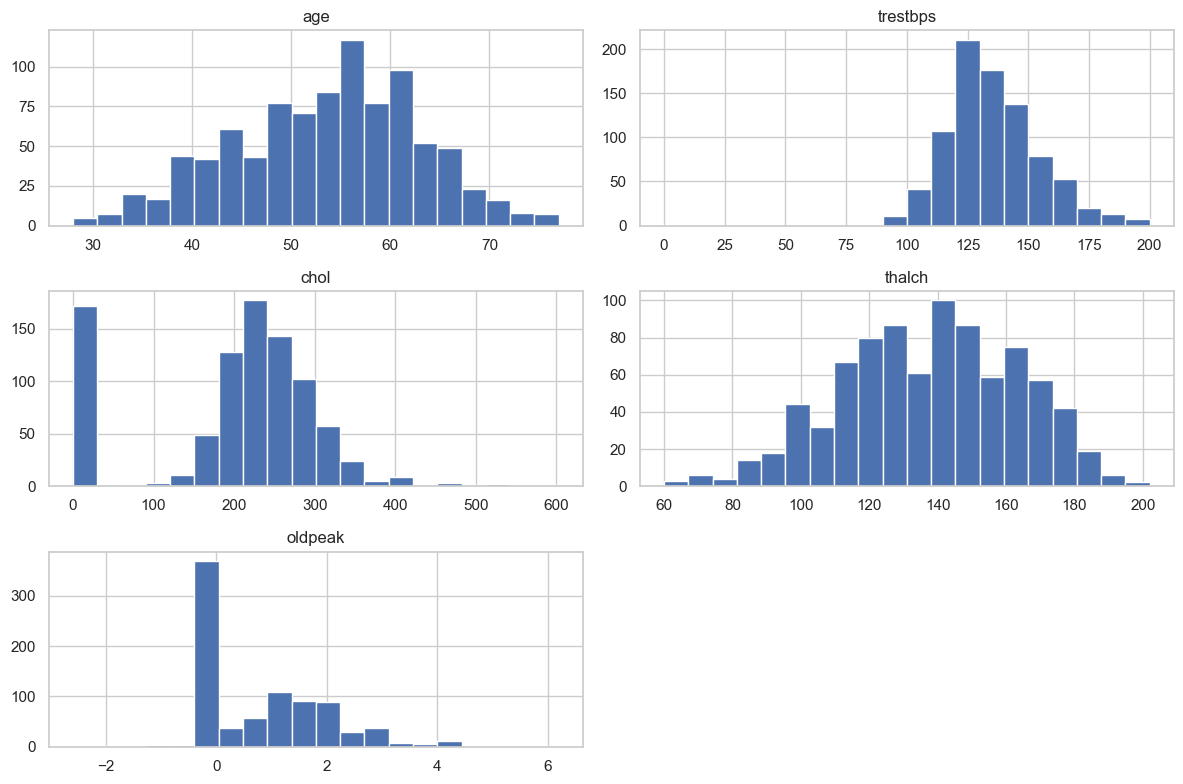

In [116]:
sns.set(style="whitegrid", context="notebook")

# Histograms for numeric features
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
df2[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()


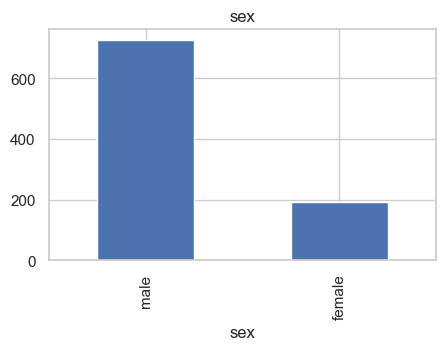

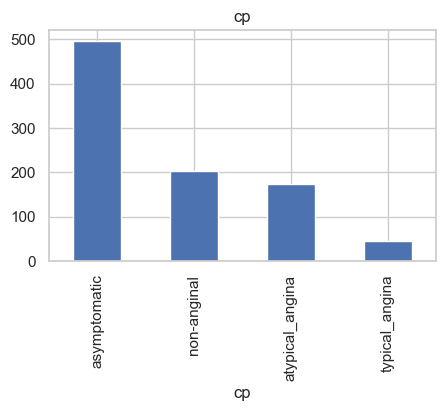

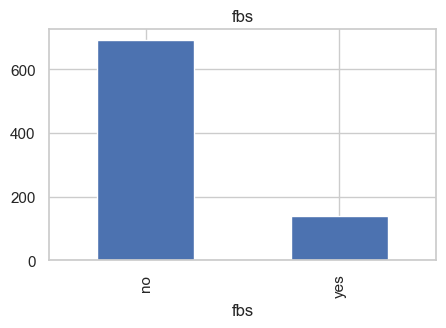

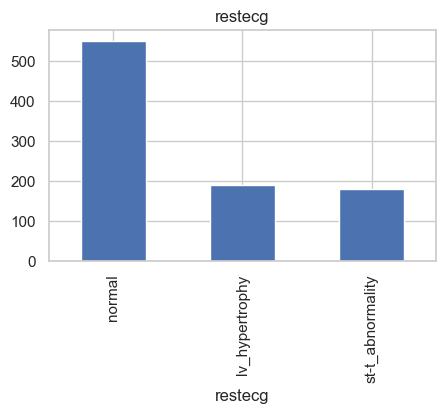

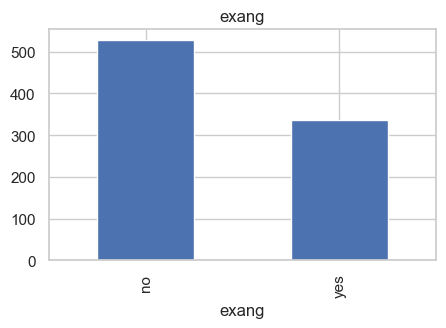

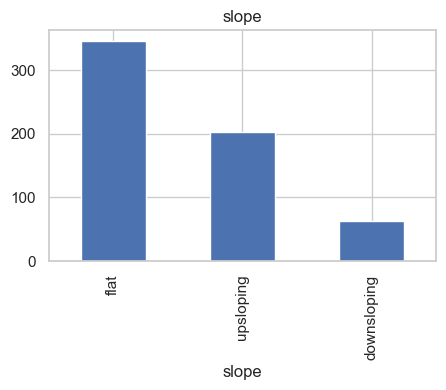

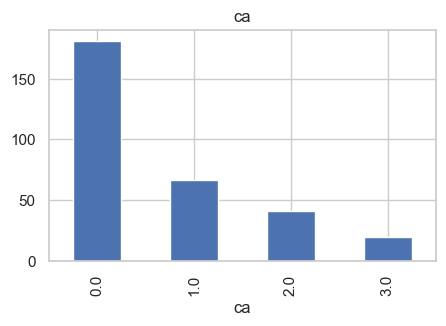

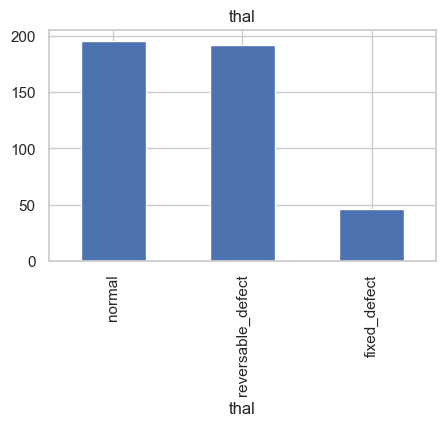

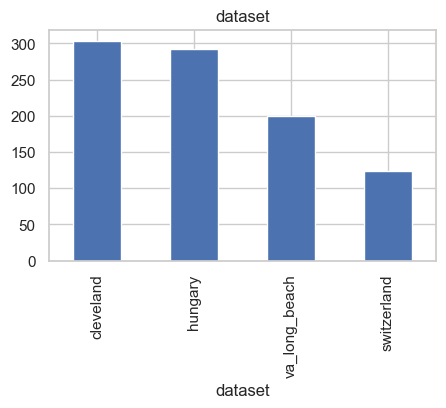

In [117]:
# Categorical / discrete variables
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "dataset"]
for c in cat_cols:
    plt.figure(figsize=(5, 3))
    df2[c].value_counts().plot(kind="bar")
    plt.title(c)
    plt.show()


In [118]:
# Target vs categorical features
for c in ["sex", "cp", "exang", "slope", "thal"]:
    ct = pd.crosstab(df2[c], df2["target"], normalize="index")
    print(c)
    print(ct)
    print("-" * 40)


sex
target         0         1
sex                       
female  0.740933  0.259067
male    0.368276  0.631724
----------------------------------------
cp
target                  0         1
cp                                 
asymptomatic     0.209677  0.790323
atypical_angina  0.861272  0.138728
non-anginal      0.645320  0.354680
typical_angina   0.565217  0.434783
----------------------------------------
exang
target         0         1
exang                     
no      0.635674  0.364326
yes     0.163690  0.836310
----------------------------------------
slope
target              0         1
slope                          
downsloping  0.222222  0.777778
flat         0.228986  0.771014
upsloping    0.615764  0.384236
----------------------------------------
thal
target                    0         1
thal                                 
fixed_defect       0.239130  0.760870
normal             0.704082  0.295918
reversable_defect  0.197917  0.802083
------------------------------

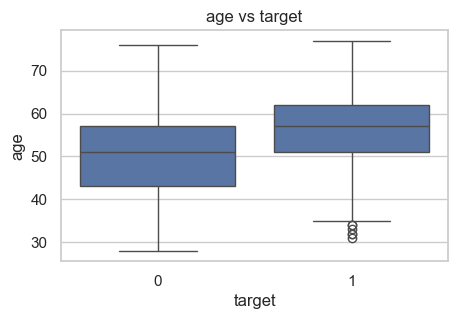

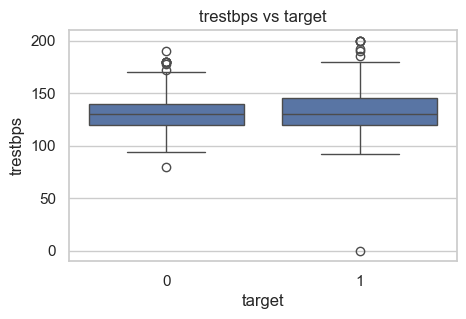

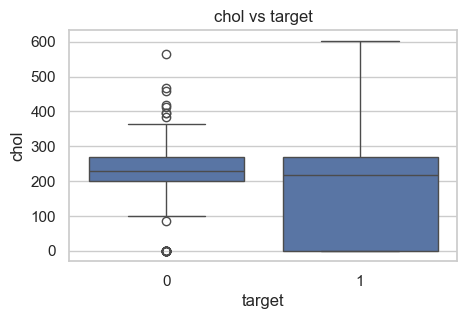

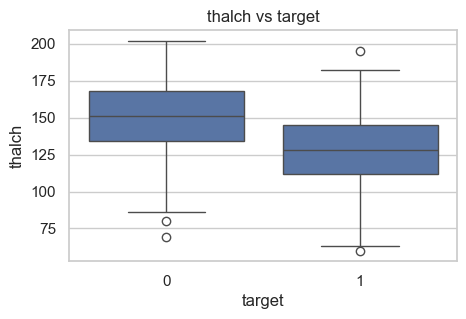

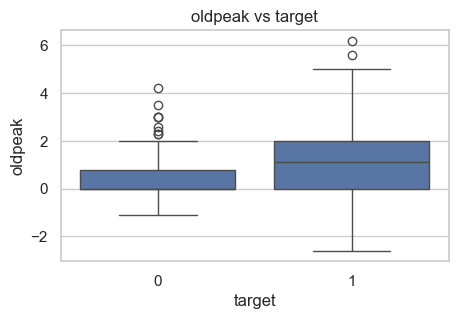

In [119]:
# Numeric features vs target (boxplots)
for c in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x="target", y=c, data=df2)
    plt.title(f"{c} vs target")
    plt.show()


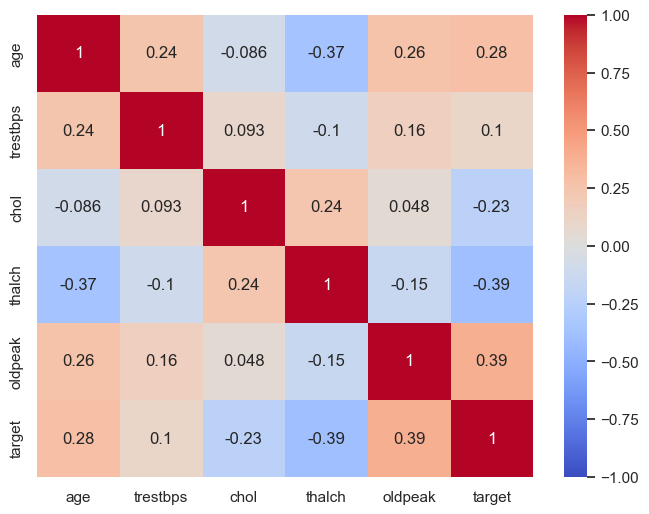

In [120]:
# Correlation heatmap for numeric + binary encoded columns
corr_cols = numeric_cols + ["target"]
plt.figure(figsize=(8, 6))
sns.heatmap(df2[corr_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [131]:
# Identify numeric and categorical columns (excluding num)
id_cols = ["id"]
target_col = "target"

numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]
categorical_features = [
    "sex", "dataset", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

# Check missing by type
print(df2[numeric_features].isna().sum())
print(df2[categorical_features].isna().sum())

age          0
trestbps    59
chol        29
thalch      55
oldpeak     62
dtype: int64
sex          0
dataset      0
cp           0
fbs         90
restecg      2
exang       55
slope      307
ca         609
thal       484
dtype: int64


In [123]:
df3=df2.copy()

In [ ]:
# Imputation
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df3[numeric_features] = num_imputer.fit_transform(df3[numeric_features])
df3[categorical_features] = cat_imputer.fit_transform(df3[categorical_features])

In [125]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    float64
 1   sex       918 non-null    object 
 2   dataset   918 non-null    object 
 3   cp        918 non-null    object 
 4   trestbps  918 non-null    float64
 5   chol      918 non-null    float64
 6   fbs       918 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    918 non-null    float64
 9   exang     918 non-null    object 
 10  oldpeak   918 non-null    float64
 11  slope     918 non-null    object 
 12  ca        918 non-null    object 
 13  thal      918 non-null    object 
 14  num       918 non-null    int64  
 15  target    918 non-null    int64  
dtypes: float64(5), int64(2), object(9)
memory usage: 114.9+ KB


In [127]:
df3["slope"].value_counts(normalize=True)

slope
flat           0.710240
upsloping      0.221133
downsloping    0.068627
Name: proportion, dtype: float64

In [142]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df3.target)

In [143]:
mi = df3[categorical_features].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

cp         0.155988
exang      0.100304
dataset    0.095112
sex        0.047477
thal       0.043793
slope      0.021645
ca         0.015100
restecg    0.006045
fbs        0.005996
dtype: float64

In [ ]:
# Features and target
#X = df[id_cols + numeric_features + categorical_features + ["num", "target"]].copy()

# Drop id and original multi-class label for modeling
#X = X.drop(columns=id_cols + ["num"])
#y = X["target"].values
#X = X.drop(columns=["target"])

In [ ]:
#df_full_train, df_test = train_test_split(X, test_size=0.2, random_state=1)
#df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [ ]:
#len(df_train), len(df_val), len(df_test)

(552, 184, 184)

In [137]:
# Features and target
X = df[id_cols + numeric_features + categorical_features + ["num", "target"]].copy()

# Drop id and original multi-class label for modeling
X = X.drop(columns=id_cols + ["num"])
y = X["target"].values
X = X.drop(columns=["target"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [153]:
# Logistic Regression Classifier
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, solver='lbfgs'))
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.842391304347826
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [160]:
y_pred = clf.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred >= 0.5))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.842391304347826
ROC AUC: 0.9256336681013869


In [152]:
# Baseline Random Forest
rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest (baseline)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest (baseline)
Accuracy: 0.8586956521739131
ROC AUC: 0.931013868962219
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        82
           1       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



In [154]:
# Parameter space for Randomized Search
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_random_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]),
    param_distributions=rf_param_dist,
    n_iter=20,             # adjust up/down depending on compute
    scoring="roc_auc",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rf_random_search.fit(X_train, y_train)

print("Best RF params:", rf_random_search.best_params_)
print("Best RF CV ROC AUC:", rf_random_search.best_score_)

best_rf = rf_random_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest (tuned) on test set")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best_rf))
print(classification_report(y_test, y_pred_best_rf))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 6}
Best RF CV ROC AUC: 0.8874591723643214
Random Forest (tuned) on test set
Accuracy: 0.8532608695652174
ROC AUC: 0.9357962697274032
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [156]:
# Baseline XGBoost
xgb_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost (baseline)")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost (baseline)
Accuracy: 0.8695652173913043
ROC AUC: 0.9161884265901482
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



In [157]:
xgb_param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.2],
    "model__min_child_weight": [1, 3, 5]
}

xgb_random_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        ))
    ]),
    param_distributions=xgb_param_dist,
    n_iter=20,             # adjust based on time/compute
    scoring="roc_auc",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

xgb_random_search.fit(X_train, y_train)

print("Best XGB params:", xgb_random_search.best_params_)
print("Best XGB CV ROC AUC:", xgb_random_search.best_score_)

best_xgb = xgb_random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
y_proba_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost (tuned) on test set")
print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best_xgb))
print(classification_report(y_test, y_pred_best_xgb))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 1.0}
Best XGB CV ROC AUC: 0.8879387159061956
XGBoost (tuned) on test set
Accuracy: 0.8586956521739131
ROC AUC: 0.9348397895743663
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        82
           1       0.84      0.92      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



In [161]:
with open("models/model_best_rf.pkl", "wb") as f_out:
    pickle.dump(best_rf, f_out)